![title](imagens/M13_deploy.jpg)

# Projeto 25 - Deploy de Modelo de ML com Flask

Vamos construir um modelo de previsão em dados históricos usando um classificador baseado em Árvore de Decisão e em seguida vamos fazer a implantação (deploy) desse modelo em uma aplicação Web utilizando Flask.
A primeira parte é a criação do Modelo. Já fizemos isso várias vezes e não vamos dar muita ênfase nisso.
Vamos focar nessa segunda parte, onde a partir de um modelo criado (que salvaremos em um arquivo), como podemos fazer o deploy em uma aplicação Web utilizando o Microframework desenvolvido em python chamado Flask.

Vamos então para a parte 1.

### Parte 1 - Criação do Modelo

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python usada neste Projeto no Jupyter Notebook:', python_version())

Versão da Linguagem Python usada neste Projeto no Jupyter Notebook: 3.11.7


In [2]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
# !pip install -q -U watermark

### Importação dos módulos / bibliotecas

In [3]:
# Importando as Bibliotecas/Pacotes
# Evitar mensagens de erros
import warnings 
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Treinamento e Métricas
import sklearn  # para registrar a versão
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Exportação do Modelo
import joblib  # para registrar a versão
from joblib import dump

# Carregar o módulo de funções para limpeza de dados
from limpeza_dados import *

# configuração do Seaborn
sns.set(style='white', context='notebook')

In [4]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "pyPRO - Seja um Profissional Python!" --iversions

Author: pyPRO - Seja um Profissional Python!

numpy     : 1.26.4
pandas    : 2.2.2
matplotlib: 3.8.4
joblib    : 1.2.0
seaborn   : 0.13.2
sklearn   : 1.2.2



### Importação do Dataset

In [5]:
# Importando o Dataset
df = pd.read_csv('dados/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


**Pré-processamento do conjunto de dados**: 
Este dataset, disponível em Kaggle: (https://www.kaggle.com/datasets/uciml/adult-census-income), é proveniente do repositório do UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/2/adult).  Estes dados foram extraídos do banco de dados do censo de 1994 por Ronny Kohavi e Barry Becker (Mineração de Dados e Visualização, Silicon Graphics).

O objetivo é predizer, diante de um conjunto de 14 atributos, se uma pessoa adulta, residente nos Estados Unidos, ganha mais ou menos que 50 mil dolares por ano ( >50K ou <=50K ).. 

**Sobre o Conjunto de Dados:**

- **Age** (Idade): Descreve a idade dos indivíduos. Contínua.

- **Workclass** (Classe de Trabalho): Privado, Autônomo-não-incorporado, Autônomo-incorporado, Governo Federal, Governo Local, Governo Estadual, Sem pagamento, Nunca trabalhou.

- **fnlwgt**: uma variável, com valor contínuo.

- **education** (Educação): Bacharelado, Alguns estudos universitários, 11º ano, Ensino médio completo, Escola profissionalizante, Associação acadêmica, Associação vocacional, 9º ano, 7º-8º ano, 12º ano, Mestrado, 1º-4º ano, 10º ano, Doutorado, 5º-6º ano, Pré-escolar.

- **education-num** (Número de Educação): Número de anos gastos na educação. Contínua.

- **marital-status** (Estado Civil): Casado com cidadão civil, Divorciado, Nunca casado, Separado, Viúvo, Casado com cônjuge ausente, Casado com cônjuge das Forças Armadas.

- **ocupation** (Ocupação): Suporte técnico, Reparo de artesanato, Outros serviços, Vendas, Executivo-gerencial, Especialidade profissional, Limpeza de manuseio, Inspeção de máquinas, Clerical administrativo, Agricultura-pesca, Transporte-mudança, Serviço de casa privada, Serviço de proteção, Forças Armadas.

- **relationship** (Relacionamento): Esposa, Filho próprio, Marido, Não na família, Outro parente, Solteiro.

- **race** (Raça): Branca, Asiática-Pacífico-Ilhéu, Ameríndio-Esquimó, Outra, Negra.

- **sex** (Sexo): Feminino, Masculino.

- **capital-gain** (Ganho de Capital): Contínua.

- **capital-loss** (Perda de Capital): Contínua.

- **hours-per-week** (Horas por Semana): Contínua.

- **native-country** (País de Origem): Estados Unidos, Camboja, Inglaterra, Porto Rico, Canadá, Alemanha, Territórios dos EUA (Guam, Ilhas Virgens Americanas etc.), Índia, Japão, Grécia, Sul, China, Cuba, Irã, Honduras, Filipinas, Itália, Polônia, Jamaica, Vietnã, México, Portugal, Irlanda, França, República Dominicana, Laos, Equador, Taiwan, Haiti, Colômbia, Hungria, Guatemala, Nicarágua, Escócia, Tailândia, Iugoslávia, El Salvador, Trinidade e Tobago, Peru, Hong Kong, Holanda.

- **salary** (Salário): >50K, <=50K

Observando os dados de análise dos dados constante no site da UCI, verificamos que os campos: `workclass`, `occupation` e `native-country` possuem valores ausentes. Dessa forma, teremos que proceder os ajustes necessários antes de submetermos esse dataset ao treinamento.

In [6]:
# Informações sobre os dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
# Descrições dos dados
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


- A idade mínima e máxima das pessoas no conjunto de dados é de 19 e 90 anos, respectivamente, enquanto a idade média é de 37 anos.
- 
O número mínimo e máximo de anos de educação é de 1 e 16, respectivamente, enquanto o nível médio de educação é de 10 anos
- 
Enquanto o ganho de capital mínimo e médio é 0, o máximo é 99999. Isso parece estranho, talvez algum erro na coleta de dado
- .
O número de horas gastas por semana varia entre 1 e 99 e a média é de 40 horas.


In [8]:
# Converte os valores desconhecidos, marcados com '?' em nulos (NA)
df.replace('?', pd.NA, inplace=True)

In [9]:
# verificando se existe algum valor nulo
calcular_porcentagem_valores_ausentes(df)

O conjunto de dados tem 0.87% de valores ausentes.


In [10]:
# Exibindo o relatório de valores nulos por coluna
relatorio_valores_ausentes_por_coluna(df)

O conjunto de dados tem 15 colunas. 
Foram encontradas 3 colunas com valores ausentes.


,Quantidade de Ausentes,Porcentagem de Ausentes,Tipo de Dado
occupation,1843,5.66,object
workclass,1836,5.64,object
native.country,583,1.79,object


### Resolvendo os dados ausentes
Resolvendo a falta de informações nos campos:  `workclass`, `occupation` e `native-country` 
Como o percentual de valores ausentes é baixo, vamos utilizar a estratégia de imputação de dados.
Existem várias maneiras de imputar valores ausentes. Analisando os dados... vamos adotar a estratégia de imputá-los usando a moda!

In [11]:
for col in ['workclass', 'occupation', 'native.country']:
    preencher_ausentes_com_moda(df, col)

1836 valores ausentes na coluna workclass foram preenchidos com a moda Private.
1843 valores ausentes na coluna occupation foram preenchidos com a moda Prof-specialty.
583 valores ausentes na coluna native.country foram preenchidos com a moda United-States.


In [12]:
# verificando se existe algum valor nulo
calcular_porcentagem_valores_ausentes(df)

O conjunto de dados tem 0.0% de valores ausentes.


In [13]:
# Exibindo o relatório de valores nulos por coluna
relatorio_valores_ausentes_por_coluna(df)

O conjunto de dados tem 15 colunas. 
Foram encontradas 0 colunas com valores ausentes.


,Quantidade de Ausentes,Porcentagem de Ausentes,Tipo de Dado


Perfeito... Vamos agora fazer algumas visualizações para entendermos os dados.

Distribuição dos dados nas duas classes: >50K, <=50K

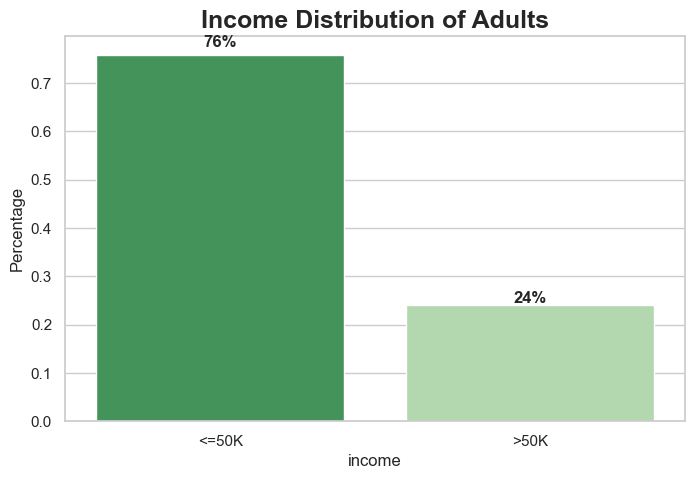

In [14]:
sns.set_style("whitegrid")
plt.figure(figsize = (8,5))
plt.title('Income Distribution of Adults', fontsize=18, fontweight='bold')
eda_percentage = df['income'].value_counts(normalize = True).rename_axis('income').reset_index(name = 'Percentage')

ax = sns.barplot(x = 'income', y = 'Percentage', data = eda_percentage.head(10), palette='Greens_r')
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy() 
    ax.annotate(f'{height:.0%}', (x + width/2, y + height*1.02), ha='center', fontweight='bold')

### Engenharia dos Dados

Para adequação dos dados para minimizar os erros de classificação.

In [30]:
# Transformação das idades em categorias: grupo de idades
def age_group(x):
    x = int(x)
    x = abs(x)
    if( 18 < x < 31 ):
        return "19-30"
    if( 30 < x < 41 ):
        return "31-40"
    if( 40 < x < 51 ):
        return "41-50"
    if( 50 < x < 61 ):
        return "51-60"
    if( 60 < x < 71 ):
        return "61-70"
    else:
        return "Greater than 70"

df['age_group'] = df['age'].apply(age_group)

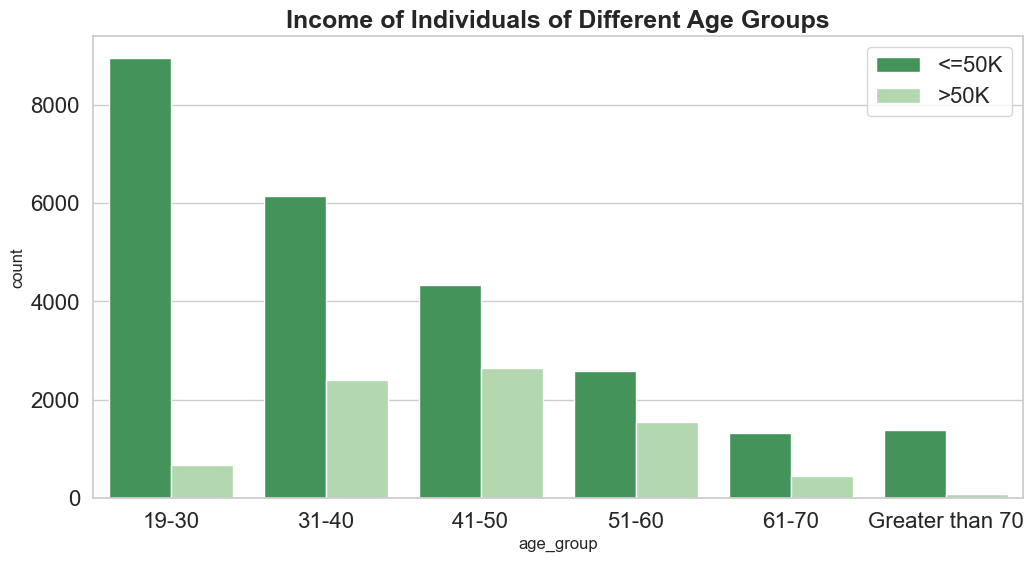

In [16]:
plt.figure(figsize=(12,6))
order_list = ['19-30', '31-40', '41-50', '51-60', '61-70', 'Greater than 70']
sns.countplot(x=df['age_group'], hue=df['income'], palette='Greens_r', order=order_list)
plt.title('Income of Individuals of Different Age Groups', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

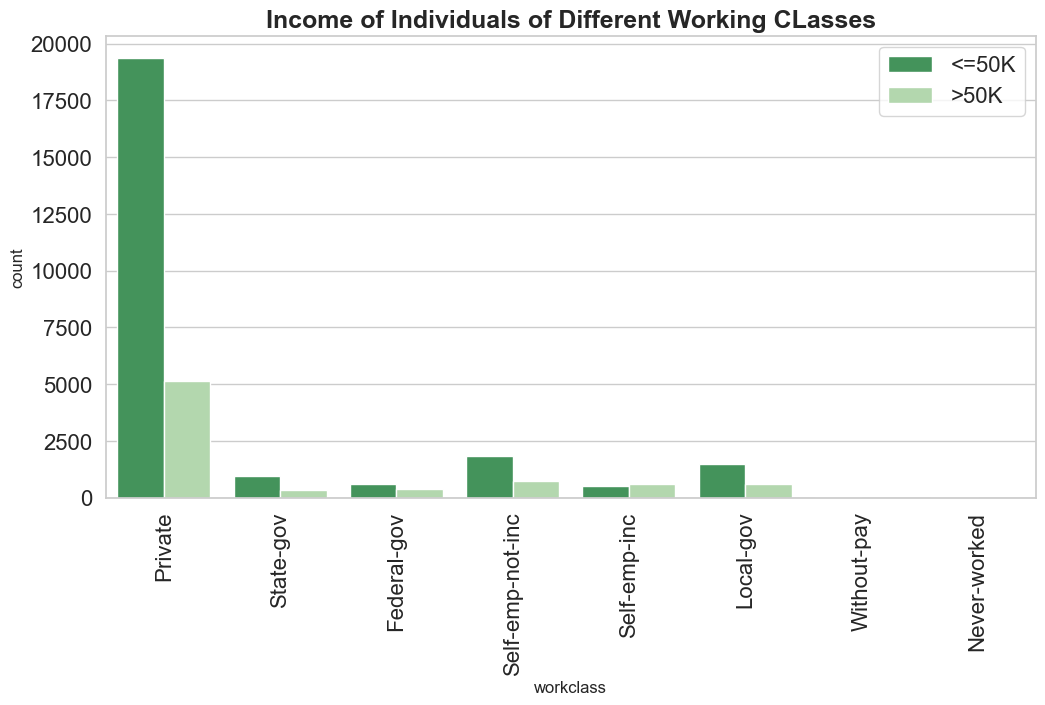

In [17]:
# Verificando a distribuição do salário por classe de trabalho
plt.figure(figsize=(12,6))
sns.countplot(x=df['workclass'], hue = df['income'], palette='Greens_r')
plt.title('Income of Individuals of Different Working CLasses', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16,rotation = 90)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

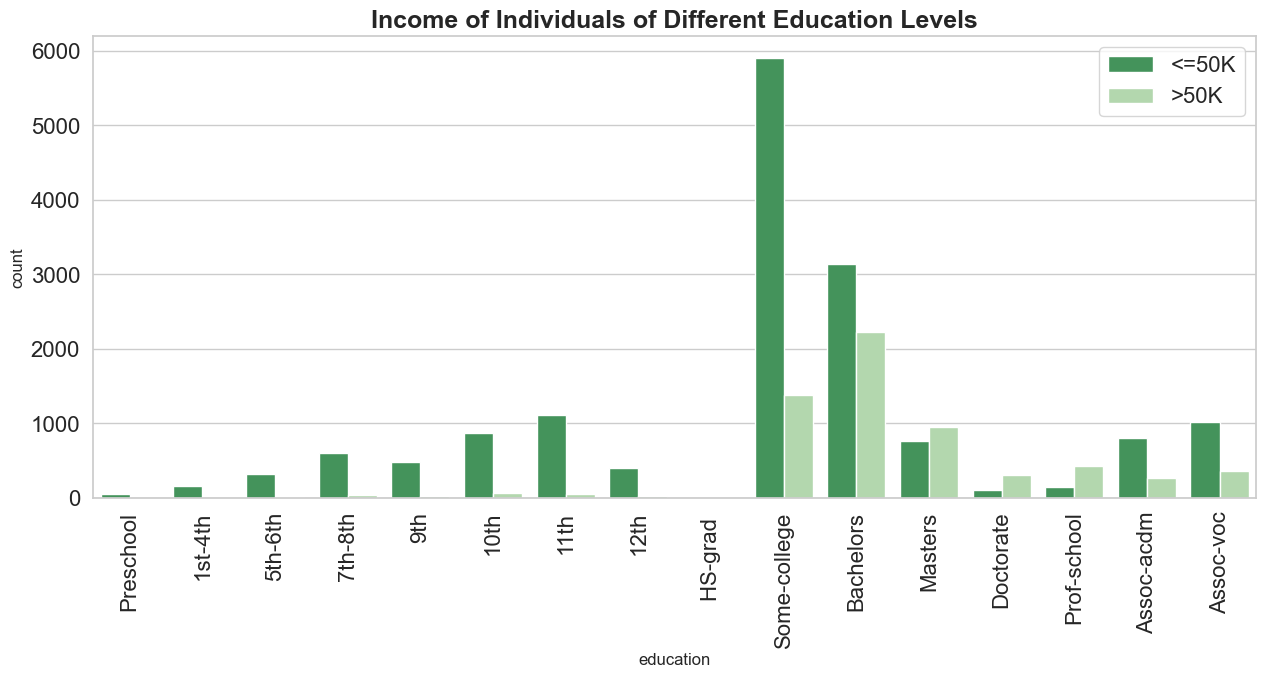

In [18]:
# Verificando o salário por escolaridade
plt.figure(figsize=(15,6))
order_list = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 
                'HS-grad ', 'Some-college', 'Bachelors', 'Masters', 'Doctorate', 'Prof-school', 
              'Assoc-acdm', 'Assoc-voc']
sns.countplot(x=df['education'], hue = df['income'], palette='Greens_r', order= order_list)
plt.title('Income of Individuals of Different Education Levels', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16,rotation = 90)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

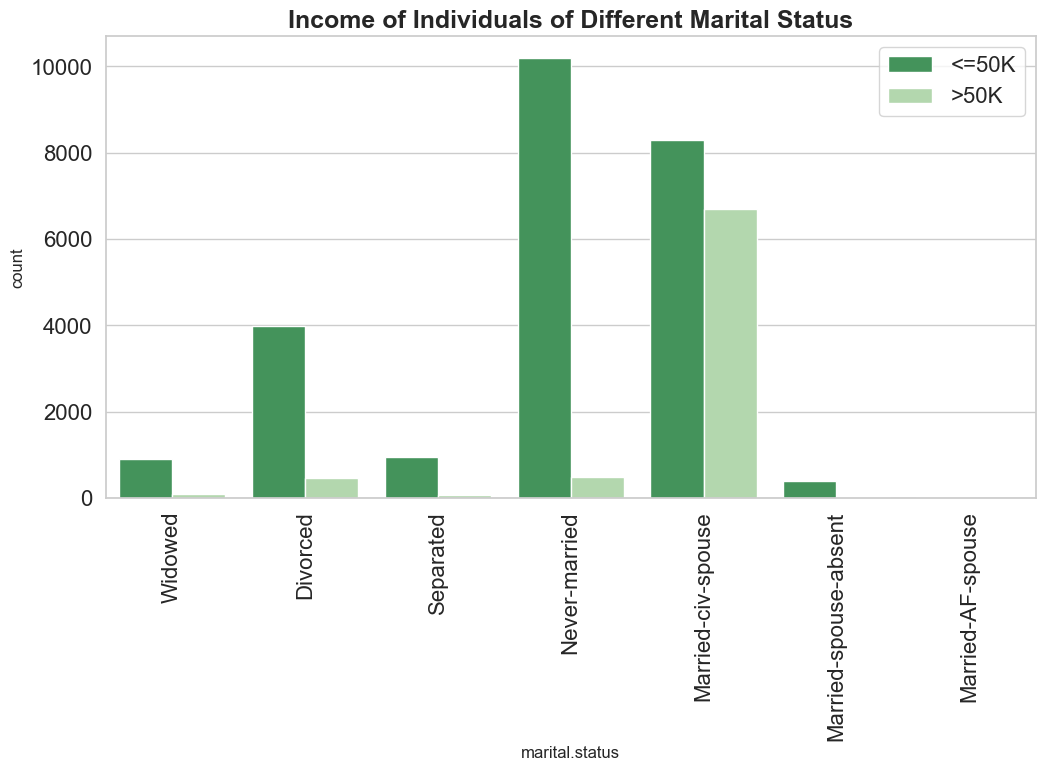

In [19]:
# Verificando o salário por Estado Civil
plt.figure(figsize=(12,6))
sns.countplot(x=df['marital.status'], hue = df['income'], palette='Greens_r')
plt.title('Income of Individuals of Different Marital Status', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16,rotation = 90)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

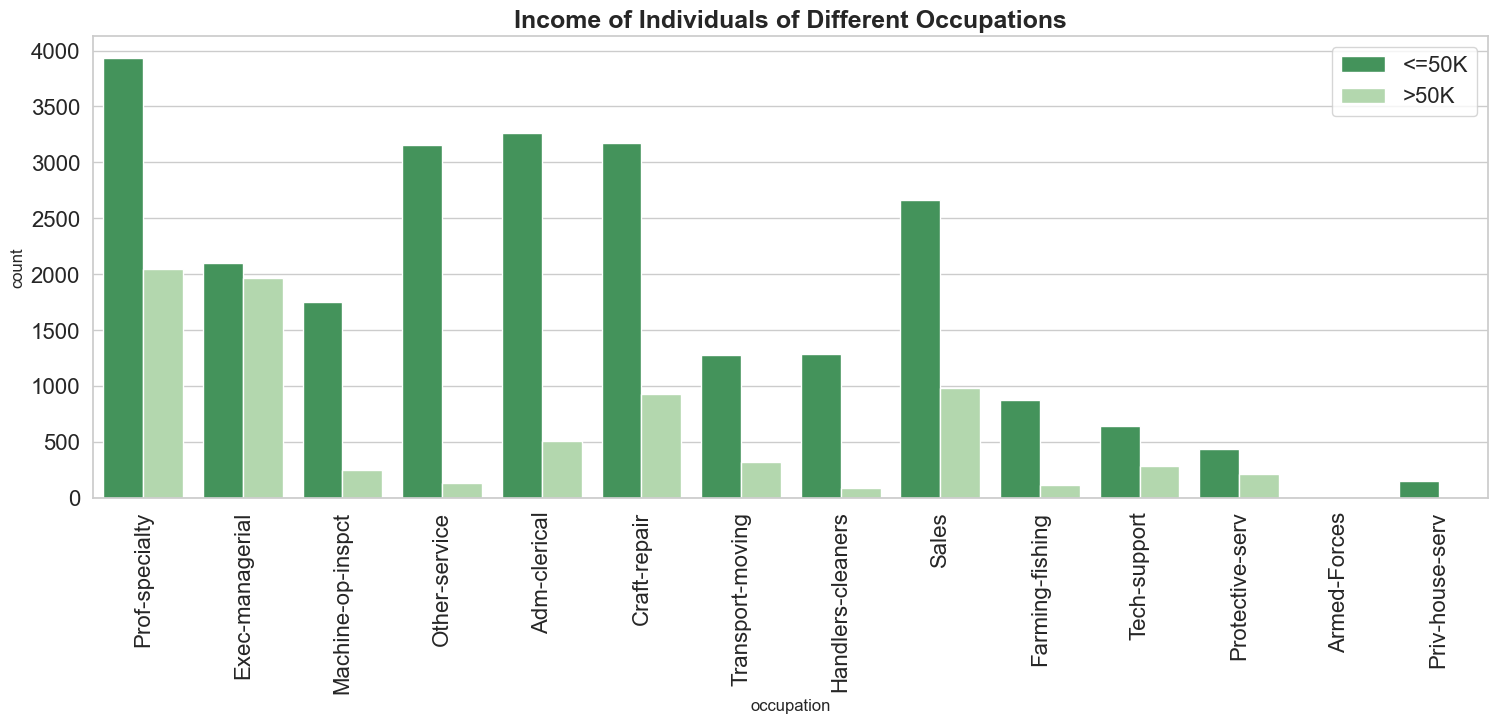

In [20]:
# Verificando o salário por tipo de ocupação
plt.figure(figsize=(18,6))
sns.countplot(x=df['occupation'], hue = df['income'], palette='Greens_r')
plt.title('Income of Individuals of Different Occupations', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16,rotation = 90)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

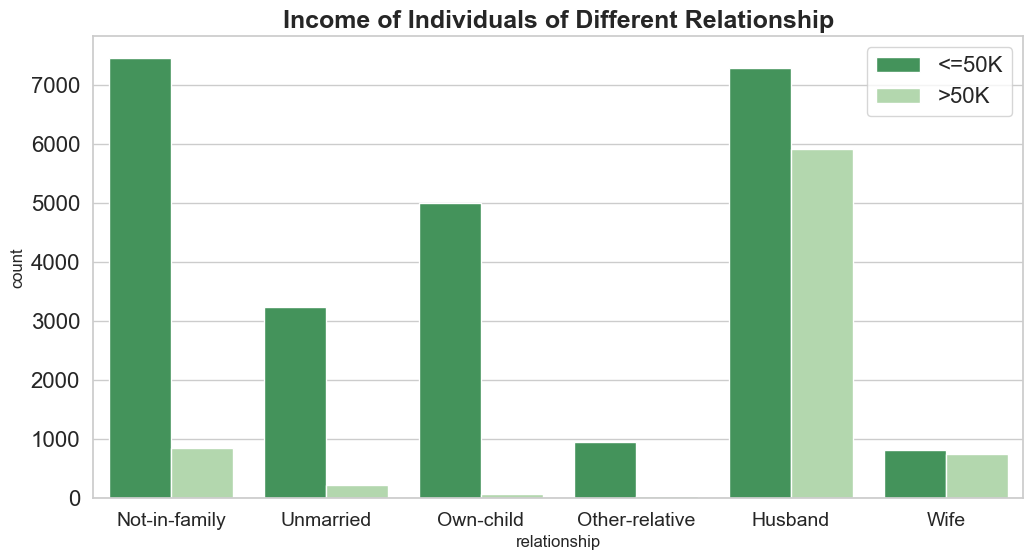

In [21]:
# Verificando o salário quanto ao tipo de relacionamento
plt.figure(figsize=(12,6))
sns.countplot(x=df['relationship'], hue = df['income'], palette='Greens_r')
plt.title('Income of Individuals of Different Relationship', fontsize=18, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

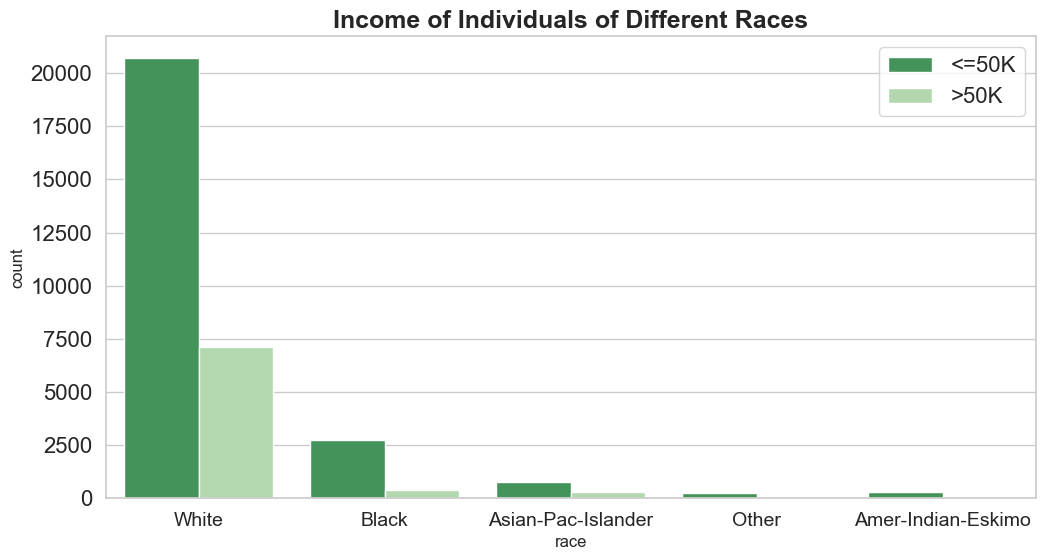

In [22]:
# Verificando o salário quanto as diferentes raças
plt.figure(figsize=(12,6))
sns.countplot(x=df['race'], hue = df['income'], palette='Greens_r')
plt.title('Income of Individuals of Different Races', fontsize=18, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

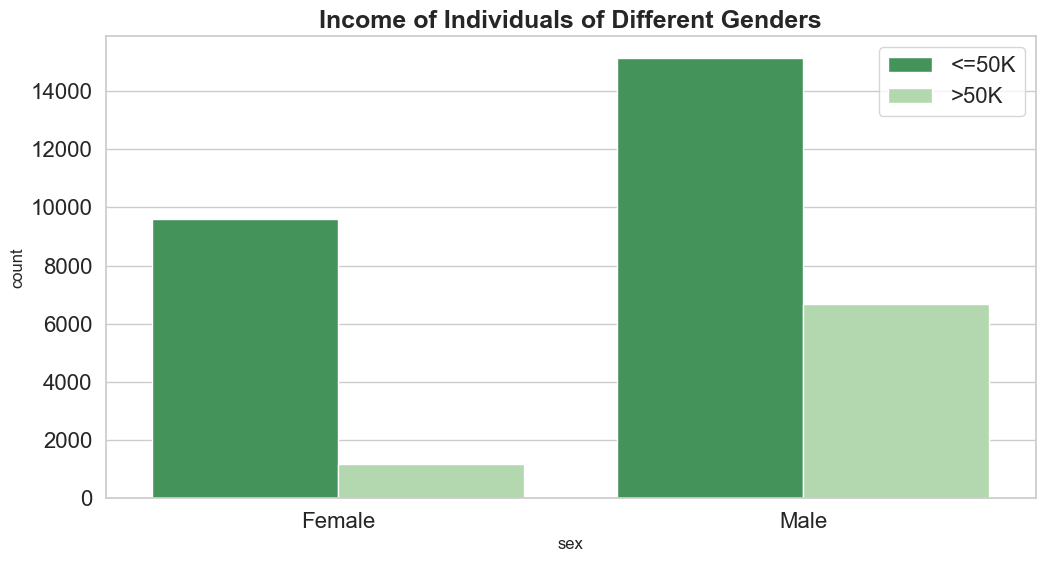

In [23]:
# Verificando o salário em relação ao sexo
plt.figure(figsize=(12,6))
#order_list = ['19-30', '31-40', '41-50', '51-60', '61-70', 'Greater than 70']
sns.countplot(x=df['sex'], hue = df['income'], palette='Greens_r')
plt.title('Income of Individuals of Different Genders', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

In [24]:
# Modificando a saída (salário) para calcular a correlação
df['income']=df['income'].map({'<=50K': 0, '>50K': 1})

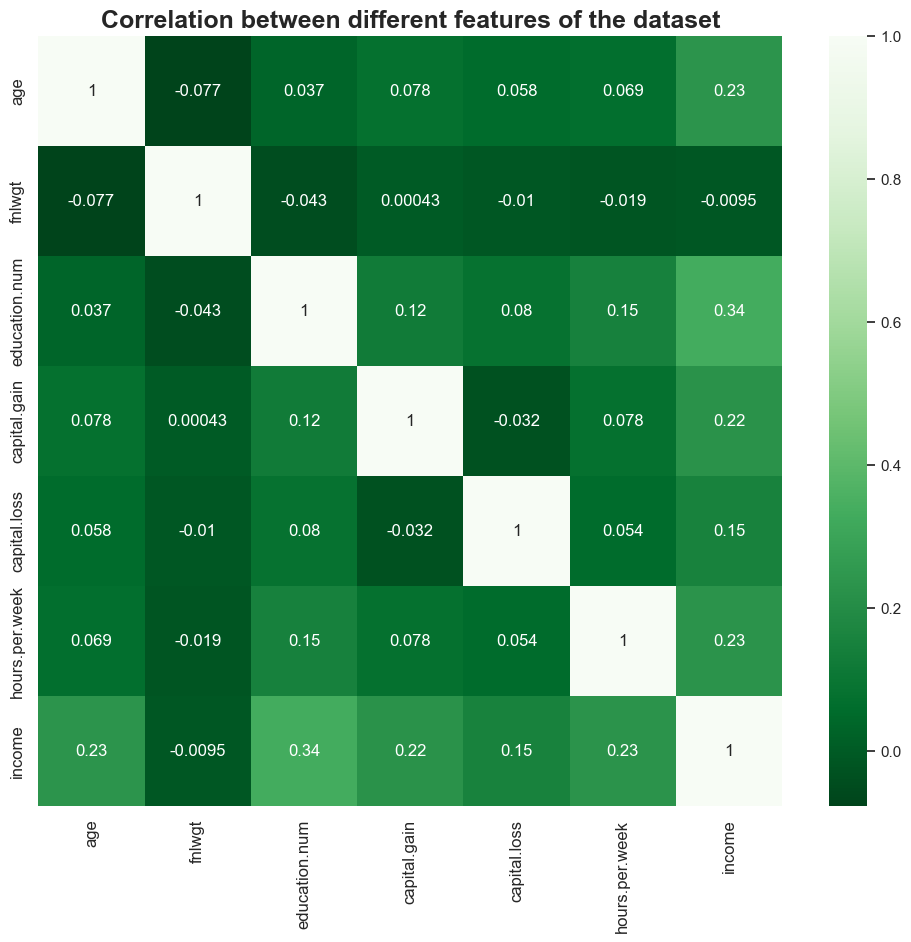

In [25]:
# Selecionar apenas as colunas numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])
# Mostrando o mapa de correlação
plt.figure(figsize=(12, 10))
plt.title("Correlation between different features of the dataset", fontsize=18, fontweight='bold')
sns.heatmap(numeric_df.corr(), cmap='Greens_r', annot=True)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12, rotation=90)
plt.show()

In [26]:
correlation_matrix = numeric_df.corr()

# Exibir a matriz de correlação
print(correlation_matrix)


                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.076646       0.036527      0.077674      0.057775   
fnlwgt         -0.076646  1.000000      -0.043195      0.000432     -0.010252   
education.num   0.036527 -0.043195       1.000000      0.122630      0.079923   
capital.gain    0.077674  0.000432       0.122630      1.000000     -0.031615   
capital.loss    0.057775 -0.010252       0.079923     -0.031615      1.000000   
hours.per.week  0.068756 -0.018768       0.148123      0.078409      0.054256   
income          0.234037 -0.009463       0.335154      0.223329      0.150526   

                hours.per.week    income  
age                   0.068756  0.234037  
fnlwgt               -0.018768 -0.009463  
education.num         0.148123  0.335154  
capital.gain          0.078409  0.223329  
capital.loss          0.054256  0.150526  
hours.per.week        1.000000  0.229689  
income                0.229689  1.000000  


In [27]:
# Distribuindo a coluna de Idade em 3 partes significativas 
# e plotando-a correspondente à característica de saída (salário)
# Combinando os graus mais baixos de educação juntos

df.drop(['education.num'], axis = 1, inplace = True)
df['education'].replace(['11th', '9th', '7th-8th', '5th-6th', '10th', '1st-4th', 'Preschool', '12th'],
                             ' School', inplace = True)
df['race'].replace(['Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other'],' Other', inplace = True)

In [31]:
# Deletando o agrupamento criado para criação dos gráficos
df.drop('age_group', inplace = True, axis = 1)

### Preparando os dados para criação dos modelos

In [32]:
# Fazendo o Encoder para poder gerar um modelo
categorical = ['workclass','education', 'marital.status', 'occupation', 'relationship',
               'race', 'sex','native.country']
label_encoder = LabelEncoder()
for col in categorical:
    label_encoder.fit(df[col])
    df[col] = label_encoder.transform(df[col])
    
# Dividindo em treino e teste
x = df[['workclass','education', 'marital.status', 'occupation', 'relationship',
               'race', 'sex','native.country', 'age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']]
y = df['income']
    
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

In [33]:
# Padronização da escala de valores
scaler = StandardScaler()

x_train = pd.DataFrame(scaler.fit_transform(x_train), columns = x.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns = x.columns)

### Gerando o Modelo com Regressão Logística

In [34]:
# Treinando o Modelo
logreg = LogisticRegression()
logreg.fit(x_train, y_train)

LogisticRegression()

In [35]:
# Fazendo as Previsões
Y_pred_log = logreg.predict(x_test)

In [36]:
# Medindo a acurácia
acc_log = accuracy_score(y_test, Y_pred_log)
print("Logistic Regression", acc_log)

Logistic Regression 0.8013102671716654


### Gerando o Modelo com Arvore de Decisão

In [37]:
# Treinando o Modelo
dectree = DecisionTreeClassifier(criterion = "gini", random_state = 100, max_depth = 5, min_samples_leaf = 5)
dectree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=100)

In [38]:
# Fazendo as Previsões
Y_pred_tree = dectree.predict(x_test)

In [39]:
# Medindo a acurácia
acc_tree = accuracy_score(y_test, Y_pred_tree)
print("Decision Tree", acc_tree)

Decision Tree 0.8291534445695568


Pela maior acurácia do segundo modelo, vamos utilizá-lo para fazer o deploy.

#### Salvando o Segundo Modelo no formato Joblib (model.joblib)

In [40]:
dump(dectree, open('model.joblib','wb'))

### Parte 2 - Deploy do Modelo

**Formulário HTML**

Primeiro, precisamos coletar os dados (novos valores de atributos) para prever a renda a partir de vários atributos e depois usar o modelo de árvore de decisão que construímos acima para prever se a renda é superior a 50 mil ou não. 

Portanto, para coletar os dados, criamos um formulário HTML que conteria todas as diferentes opções para selecionar de cada atributo. Aqui, criamos um formulário simples usando apenas HTML. Se você tiver conhecimento e desejar tornar o formulário mais interativo, fique a vontade para fazer isso.

**Carregando o Modelo Salvo**

In [ ]:
# joblib --> load  (from joblib import load)

loaded_model = load(open('model.joblib','rb'))

Isso dentro do código Flask ficaria da seguinte forma:

In [ ]:
# libraries installation
# pip install scikit-learn==1.2.2
# pip install numpy==1.26.4
# pip install joblib==1.2.0

#importing libraries
import os
import numpy as np
import flask
from joblib import load
from flask import Flask, render_template, request

#creating instance of the class
app=Flask(__name__)

#to tell flask what url shoud trigger the function index()
@app.route('/')
@app.route('/index')
def index():
    return flask.render_template('index.html')
    #return "Hello World"

#prediction function
def ValuePredictor(to_predict_list):
    to_predict = np.array(to_predict_list).reshape(1,13)
    loaded_model = load(open("model.joblib","rb"))
    result = loaded_model.predict(to_predict)
    return result[0]


@app.route('/result',methods = ['POST'])
def result():
    if request.method == 'POST':
        to_predict_list = request.form.to_dict()
        to_predict_list=list(to_predict_list.values())
        to_predict_list = list(map(int, to_predict_list))
        result = ValuePredictor(to_predict_list)
        
        if int(result)==1:
            prediction='Renda superior a 50K'
        else:
            prediction='Renda inferior a 50K'
            
        return render_template("result.html",prediction=prediction)

if __name__ == "__main__":
	app.run(debug=True)

#### Basta executar e acessar a página que será indicada...

## Fim do Projeto 25